In [204]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Data Preparation

In [205]:
# load the timeseries data in
one = pd.read_csv("data/FOREXCOM_NAS100, 60_2f4cb.csv")
two = pd.read_csv("data/FOREXCOM_NAS100, 60_b7d08.csv")

# concat the two datasets into one
nasdaq = pd.concat([one, two], axis=0, ignore_index=True)
nasdaq.to_csv("data/nasdaq.csv")

In [206]:
nasdaq.head()

,time,open,high,low,close,VWAP,Upper Band,Lower Band,Middle of Bands,Slow MA,VWAP.1
0,2019-01-02T00:00:00+01:00,6335.7,6366.3,6331.6,6359.7,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-02T01:00:00+01:00,6359.6,6371.2,6356.9,6364.8,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-02T02:00:00+01:00,6364.9,6371.1,6330.3,6332.1,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-02T03:00:00+01:00,6332.2,6333.9,6279.4,6293.4,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-02T04:00:00+01:00,6293.3,6294.9,6281.3,6290.3,NaN,NaN,NaN,NaN,NaN,NaN


In [207]:
nasdaq.shape

(46433, 11)

In [208]:
nasdaq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46433 entries, 0 to 46432
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             46433 non-null  object 
 1   open             46433 non-null  float64
 2   high             46433 non-null  float64
 3   low              46433 non-null  float64
 4   close            46433 non-null  float64
 5   VWAP             0 non-null      float64
 6   Upper Band       46325 non-null  float64
 7   Lower Band       46325 non-null  float64
 8   Middle of Bands  46325 non-null  float64
 9   Slow MA          46389 non-null  float64
 10  VWAP.1           0 non-null      float64
dtypes: float64(10), object(1)
memory usage: 3.9+ MB


In [209]:
nasdaq[nasdaq["time"].str.contains(r"^\d{4}-\d{2}-\d{2}T23")]

,time,open,high,low,close,VWAP,Upper Band,Lower Band,Middle of Bands,Slow MA,VWAP.1
46,2019-01-03T23:00:00+01:00,6161.9,6161.9,6161.9,6161.9,NaN,NaN,NaN,NaN,39.992779,NaN
93,2019-01-07T23:00:00+01:00,6492.1,6492.1,6492.1,6492.1,NaN,71.322016,56.094332,63.708174,63.986113,NaN
117,2019-01-08T23:00:00+01:00,6540.5,6540.5,6540.5,6540.5,NaN,67.972176,56.570632,62.271404,59.116859,NaN
141,2019-01-09T23:00:00+01:00,6591.5,6591.5,6591.5,6591.5,NaN,65.620202,55.805743,60.712973,57.866596,NaN
165,2019-01-10T23:00:00+01:00,6614.1,6614.1,6614.1,6614.1,NaN,64.070243,45.346996,54.708619,59.002604,NaN
...,...,...,...,...,...,...,...,...,...,...,...
46156,2026-09-02T23:00:00+02:00,29096.5,29096.5,29096.0,29096.0,NaN,49.067484,32.202791,40.635138,47.863474,NaN
46291,2026-09-10T23:00:00+02:00,29115.7,29116.0,29115.7,29116.0,NaN,50.902862,34.382745,42.642804,37.563880,NaN
46338,2026-09-14T23:00:00+02:00,29171.7,29171.7,29171.1,29171.1,NaN,61.158814,31.356994,46.257904,51.826591,NaN
46362,2026-09-15T23:00:00+02:00,28971.3,28971.3,28971.1,28971.1,NaN,55.155227,39.283303,47.219265,44.010164,NaN


Some of the 23 hour data are missing. First I will leave it in the dataset, them I will remove and see how the model performs.

In [210]:
close = nasdaq["close"].copy()

In [211]:
close.isna().sum()

np.int64(0)

In [212]:
close.duplicated().sum() # safe to ignore, if datetime is added, then these duplicates disappear

np.int64(4743)

Since the Nasdaq changed price regions over the years applying minmax or standardscaler would distort the ingestion pipeline. First I need to extract the market dynamics and move away from price levels to logarithmic returns. This is the same over the years.

Text(0.5, 0, 'Log-returns')

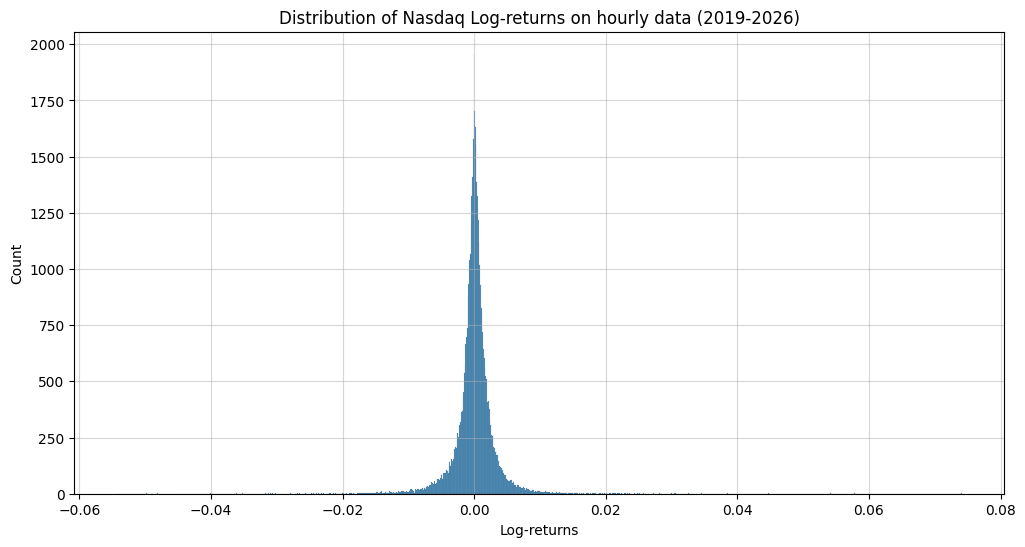

In [213]:
log_returns = np.log(close / close.shift(1))
log_returns = log_returns.dropna()
plt.figure(figsize=[12,6])
plt.grid(alpha=0.5, zorder=2)
sns.histplot(log_returns)
plt.title("Distribution of Nasdaq Log-returns on hourly data (2019-2026)", zorder=1)
plt.xlabel("Log-returns")

In [214]:
from sklearn.preprocessing import StandardScaler

In [215]:
scaler = StandardScaler()

length = len(log_returns)
train = log_returns[:int(length * 0.7)]
valid = log_returns[int(length * 0.7):int(length * 0.85)]
test = log_returns[int(length * 0.85):]

train_scaled = scaler.fit_transform(train.to_numpy().reshape(-1,1))
valid_scaled = scaler.transform(valid.to_numpy().reshape(-1,1))
test_scaled = scaler.transform(test.to_numpy().reshape(-1,1))

print(train_scaled.shape)
print(valid_scaled.shape)
print(test_scaled.shape)

(32502, 1)
(6965, 1)
(6965, 1)


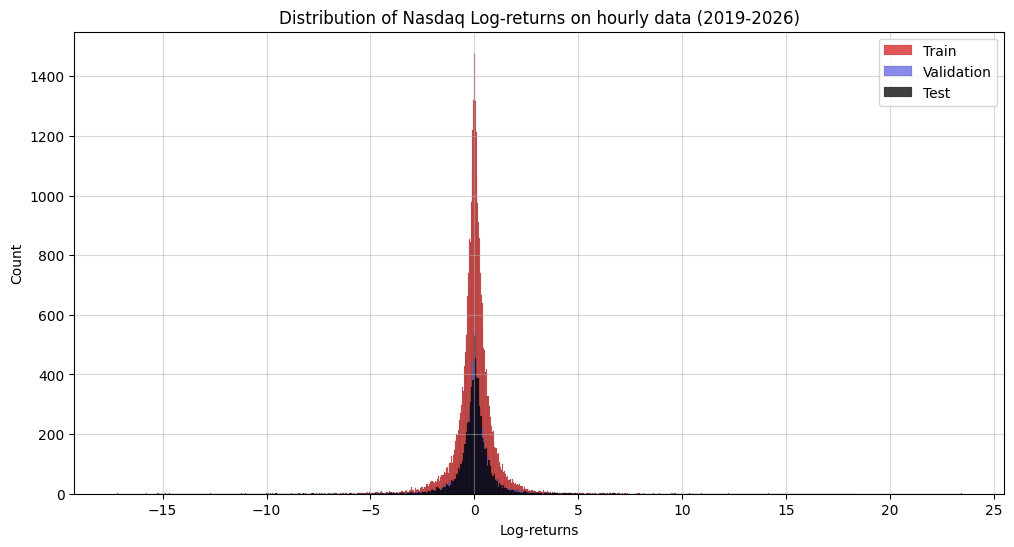

In [216]:
plt.figure(figsize=[12,6])
plt.grid(alpha=0.5, zorder=2)
sns.histplot(train_scaled.flatten(), label="Train", color="#D81E1E", fill=True)
sns.histplot(valid_scaled.flatten(), label="Validation", color="#6165E6", fill=True)
sns.histplot(test_scaled.flatten(), label="Test", color="#000000", fill=True)
plt.title("Distribution of Nasdaq Log-returns on hourly data (2019-2026)", zorder=1)
plt.xlabel("Log-returns")
plt.legend()
plt.show()

This plot reassures that the log-returns are stationaty and they catch the nasdaq`s dynamics. All three of the sets cleanly center around the mean. The huge skewness to the right and to the left is not surprising. It is a asset market, where human emotion and speculation is involved.

# 2. Data Ingestion Pipeline

## 2.1 Predicting the next hourly candle close

In [217]:
steps_in = 50
steps_out = 1
total_window_size = steps_in + steps_out 

# 1. Create a dataset of 57-step windows
train_df = tf.keras.utils.timeseries_dataset_from_array(
    data=train_scaled,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=1,
    shuffle=True,
    batch_size=32
)

valid_df = tf.keras.utils.timeseries_dataset_from_array(
    data=valid_scaled,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=1,
    shuffle=False,
    batch_size=32
)

test_df = tf.keras.utils.timeseries_dataset_from_array(
    data=test_scaled,
    targets=None,
    sequence_length=total_window_size,
    sequence_stride=1,
    shuffle=False,
    batch_size=32
)

# 2. Split each batch into X (first 50 steps) and y (next 7 steps)
def split_window(window):
    x = window[:, :steps_in, :]
    y = window[:, steps_in:, :]
    return x, y

train_df = train_df.map(split_window)
valid_df = valid_df.map(split_window)
test_df = test_df.map(split_window)

# 3. Building the model

In [218]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

## 3.1.1 Naive forecast

In [253]:
# extract last step of train
# extract actual next steps t+1
time_stride = 1
y_pred_1 = []
y_valid_1 = []

for x, y in valid_df:
    last_val = x[:, -1, :].numpy()
    naive_forecast = np.repeat(last_val, repeats=time_stride, axis=1)

    y_pred_1.append(naive_forecast)
    y_valid_1.append(y.numpy())

y_pred_1 = np.concatenate(y_pred_1, axis=0).reshape(-1)  
y_valid_1 = np.concatenate(y_valid_1, axis=0).reshape(-1)

mse1_naive = round(mean_squared_error(y_valid_1, y_pred_1), 4)
mape1_naive = round(mean_absolute_percentage_error(y_valid_1, y_pred_1), 2)

print(f"The MAE is: {mse1_naive} and the MAPE is: {mape1_naive}%")

The MAE is: 1.8231 and the MAPE is: 6.14%


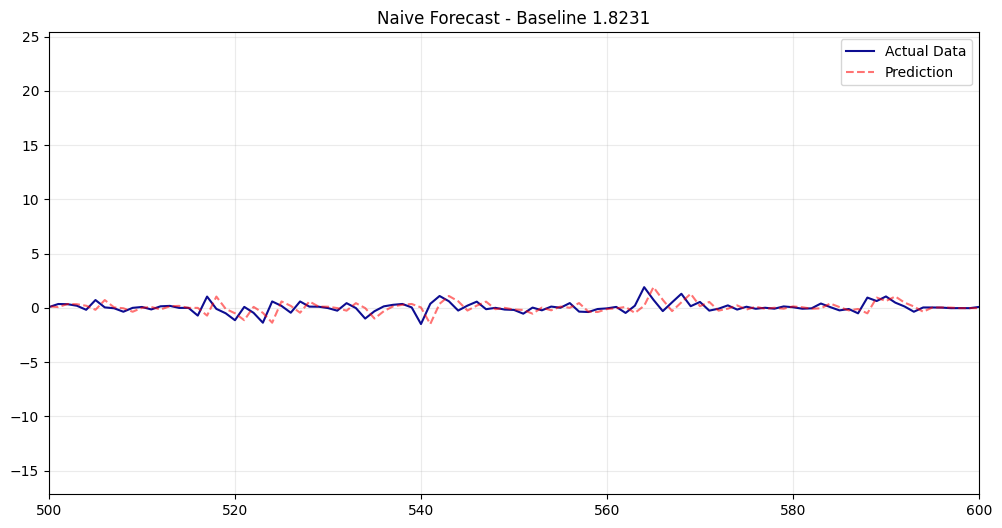

In [257]:
plt.figure(figsize=[12,6])

steps = np.arange(50, len(y_pred_1)+50, 1)
plt.plot(valid_scaled ,color="darkblue", alpha=0.95, label="Actual Data")
plt.plot(steps, y_pred_1, "r--", alpha=0.55, label="Prediction")
plt.title(f"Naive Forecast - Baseline {mse1_naive}")
plt.xlim(500,600)
plt.grid(alpha=0.25)
plt.legend()

Well, the naive forecast too simple and the market is too complex. Lets start adding more model variance.

## 3.1.2 Linear model

In [221]:
linear_model = keras.models.Sequential([
    keras.layers.Input(shape=[50,1]),
    keras.layers.Reshape((50,)),
    keras.layers.Dense(1)
])
linear_model.compile(loss="mse", metrics=["mae"], optimizer="adam")

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=5,
    factor=0.5,
    verbose=1,
    min_lr=1e-6
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10
)


linear_model.fit(train_df, validation_data=valid_df, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 1s 917us/step - loss: 2.2741 - mae: 0.9920 - val_loss: 0.9784 - val_mae: 0.5703 - learning_rate: 0.0010
Epoch 2/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 1s 898us/step - loss: 1.0395 - mae: 0.6034 - val_loss: 0.9211 - val_mae: 0.5419 - learning_rate: 0.0010
Epoch 3/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 1s 814us/step - loss: 1.0151 - mae: 0.5866 - val_loss: 0.9219 - val_mae: 0.5429 - learning_rate: 0.0010
Epoch 4/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 1s 834us/step - loss: 1.0098 - mae: 0.5858 - val_loss: 0.9228 - val_mae: 0.5432 - learning_rate: 0.0010
Epoch 5/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 1s 859us/step - loss: 1.0173 - mae: 0.5874 - val_loss: 0.9227 - val_mae: 0.5432 - learning_rate: 0.0010
Epoch 6/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 1s 809us/step - loss: 1.0126 - mae: 0.5865 - val_loss: 0.9230 - val_mae: 0.5436 - learning_rate: 0.0010
Epoch 7/50
 984/1015 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step - loss: 1.0139 - mae: 0.5870
Epoch 7: ReduceLROnPlateau reducing lea

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 971us/step - loss: 0.6772 - mae: 0.4868


(5000.0, 5100.0)

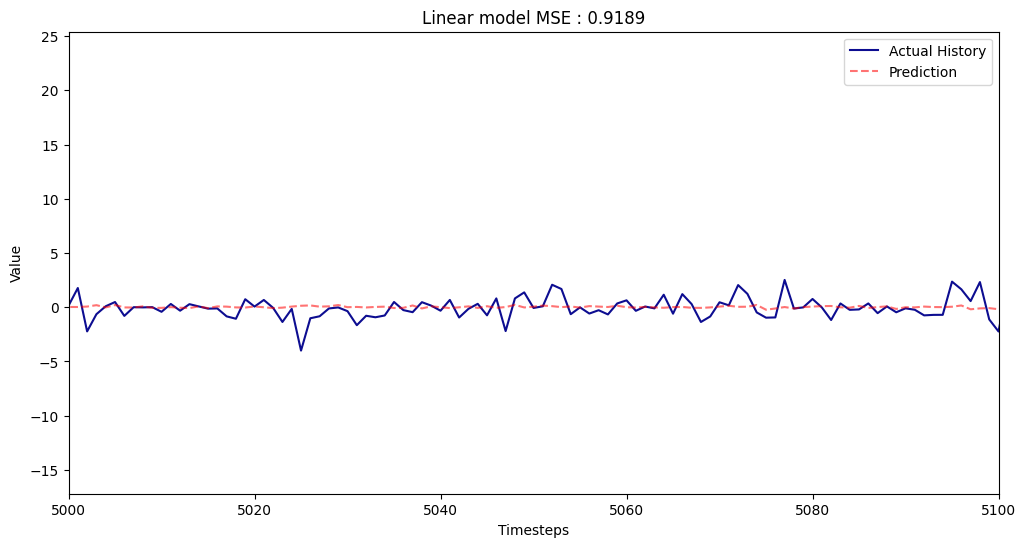

In [262]:
y_pred1_linear = linear_model.predict(valid_df)
mse1_linear = round(linear_model.evaluate(valid_df)[0],4)


plt.figure(figsize=[12, 6])
plt.plot(valid_scaled, label="Actual History", color="darkblue", alpha=0.95)
plt.plot(steps, y_pred1_linear, "r--", label="Prediction", alpha=0.55)
plt.legend()
plt.title(f"Linear model MSE : {mse1_linear}")
plt.xlabel("Timesteps")
plt.ylabel("Value")
plt.xlim(5000, 5100)

## 3.1.3 SimpleRNN

In [267]:
srnn_model = keras.models.Sequential([
    keras.layers.Input(shape=[None,1]),
    keras.layers.SimpleRNN(32),
    keras.layers.Dense(1)
])
optimizer = tf.keras.optimizers.Adam(learning_rate=0.1)
srnn_model.compile(loss="mse", metrics=["mae"], optimizer=optimizer)
srnn_model.fit(train_df, validation_data=valid_df, epochs=50, callbacks=[early_stop, reduce_lr])

Epoch 1/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.2148 - mae: 0.7128 - val_loss: 2.5067 - val_mae: 1.3538 - learning_rate: 0.1000
Epoch 2/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.1987 - mae: 0.7146 - val_loss: 0.9098 - val_mae: 0.5333 - learning_rate: 0.1000
Epoch 3/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.1379 - mae: 0.6749 - val_loss: 0.9255 - val_mae: 0.5569 - learning_rate: 0.1000
Epoch 4/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.1699 - mae: 0.7003 - val_loss: 0.9906 - val_mae: 0.6214 - learning_rate: 0.1000
Epoch 5/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.1469 - mae: 0.6869 - val_loss: 0.9070 - val_mae: 0.5327 - learning_rate: 0.1000
Epoch 6/50
 889/1015 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1952 - mae: 0.7130

KeyboardInterrupt: 

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 0.6772 - mae: 0.4868


(5000.0, 5100.0)

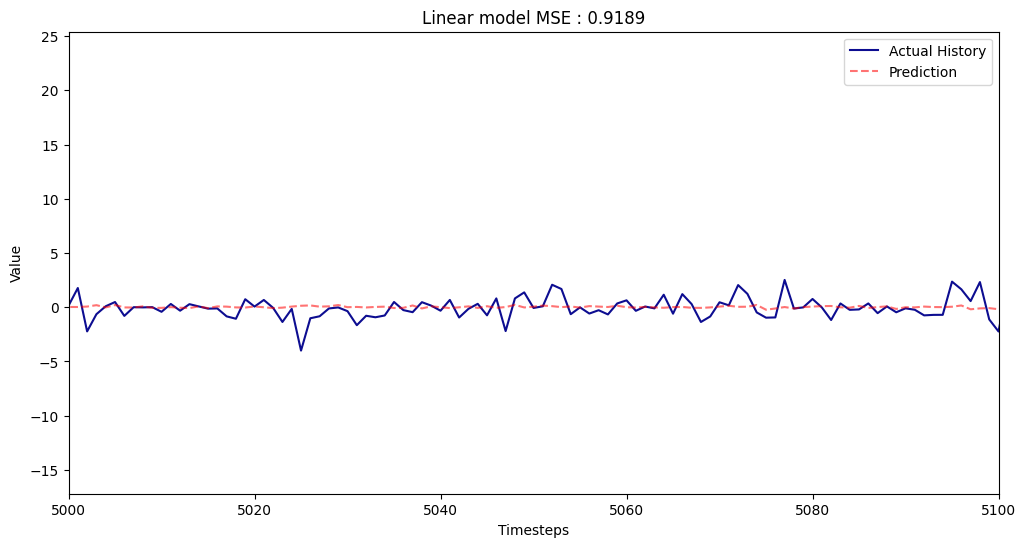

In [266]:
y_pred1_srnn = linear_model.predict(valid_df)
mse1_srnn = round(linear_model.evaluate(valid_df)[0],4)


plt.figure(figsize=[12, 6])
plt.plot(valid_scaled, label="Actual History", color="darkblue", alpha=0.95)
plt.plot(steps, y_pred1_srnn, "r--", label="Prediction", alpha=0.55)
plt.legend()
plt.title(f"Linear model MSE : {mse1_srnn}")
plt.xlabel("Timesteps")
plt.ylabel("Value")
plt.xlim(5000, 5100)